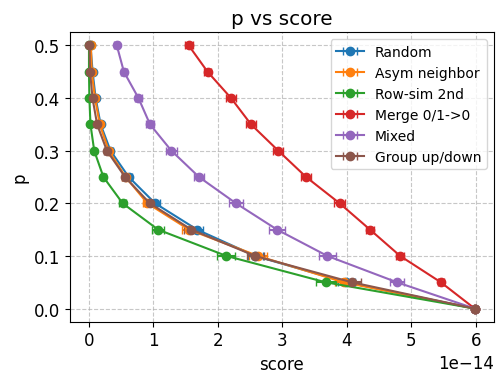

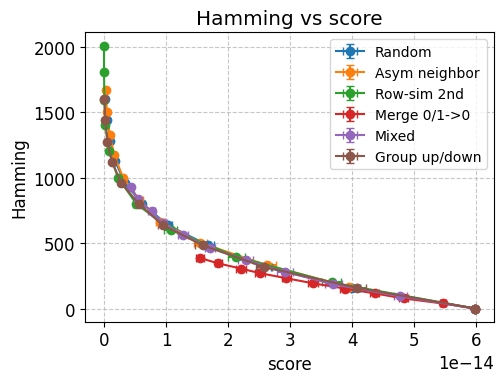

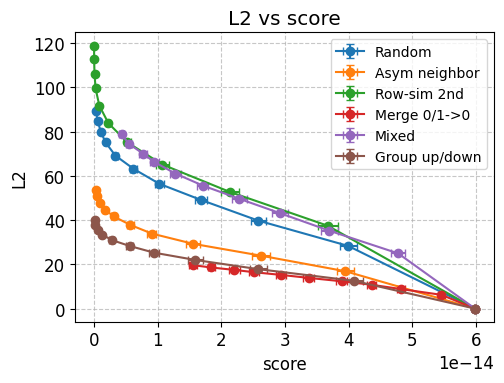

In [1]:
# =============================================================================
# Section 5.1 -- Synthetic Categorical Data (Figure 2)
# =============================================================================
# Experiment 1: plug-in Gram determinant score on categorical Y.
# Setup: N=4000 samples, d=5 classes, M=100 Monte Carlo runs.
# Notation (paper Sec. 2):
#   x  = true class label (X below)
#   x^ = reported label   (X_hat)
#   y  = observation      (Y)
#   P  = d x d experiment matrix, P[x,y] = P(Y=y | X=x)  (unknown to scorer)
#   Q  = misreport matrix Q[i,j] = freq(x=i, x^=j)
# -----------------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import det, norm

# Reproducibility
rng = np.random.default_rng(42)

# -----------------------------
# Setup
# -----------------------------
n = 4000
d = 5
ps = np.arange(0.5, 1.0001, 0.05)   # keep-prob grid; corruption rate = 1-p
n_runs = 100  # Monte Carlo replications

# P: ground-truth experiment matrix (P[x,y] = P(y|x)), rows sum to 1.
# In practice P is UNKNOWN to the scorer -- only x^ and y are observed.
P = rng.random((d, d))
P = P / P.sum(axis=1, keepdims=True)

# Data: X ~ Uniform{0..d-1}, and Y ~ P[X]  (Section 5.1, data generation)
X = rng.integers(0, d, size=n)
Y = np.array([rng.choice(d, p=P[x]) for x in X])

# Precompute neighbor maps for manipulation policies (Section 5.1, Eq. 9)
neighbor_plus = np.arange(d) + 1
neighbor_plus[-1] = d - 1
neighbor_minus = np.arange(d) - 1
neighbor_minus[0] = 0

# For "Row-sim 2nd" policy: nearest other class by cosine similarity of P rows
row_norm = np.linalg.norm(P, axis=1, keepdims=True) + 1e-12
P_unit = P / row_norm
S = P_unit @ P_unit.T
np.fill_diagonal(S, -np.inf)
second_class = S.argmax(axis=1)  # second_class[x] = argmax_{j!=x} cos(P_x, P_j)

# Definition 4.5 (plug-in estimator, delta kernel K=1[y=y']):
#   G^[x,x'] = (1/N^2) sum_{n: x^_n=x} sum_{n': x^_{n'}=x'} 1[y_n=y_{n'}]
# Equivalently, let C[x,y] = count(x^=x, obs=y)/N; then G^ = C @ C^T / N^2...
# but since K is the delta kernel, G^(x,x') = sum_y C[x,y]*C[x',y].
# Score = det(G^)^2  (= det(C C^T)  for square C)
def confusion_det_sq(xh, y, d):
    # Build empirical joint C[x^, y]: rows=reported class, cols=observation
    G = np.zeros((d, d), dtype=float)
    np.add.at(G, (xh, y), 1)
    G /= len(xh)           # C = joint frequency table (x^, y)
    return float(det(G) ** 2)  # Gamma = det(G^)^2; G^ = C @ C^T but det(C@C^T)=det(C)^2

# "Mixed" (human-like) manipulation policy: Dirichlet misreport matrix
# with diagonal dominance, locality (ring topology), upcoding bias (Section 5.1)
def human_like_confusion(d=5,
                         diag_strength=25.0,
                         off_strength=1.2,
                         beta=5.0,
                         default_bias=0.20,
                         default_label=0,
                         upcode_alpha=1.0,
                         topology="ring",
                         rng=None):
    rng = np.random.default_rng() if rng is None else rng
    idx = np.arange(d)
    if topology == "ring":
        dist = np.minimum(np.abs(idx[:, None] - idx[None, :]),
                          d - np.abs(idx[:, None] - idx[None, :]))
    elif topology == "line":
        dist = np.abs(idx[:, None] - idx[None, :])
    else:
        dist = np.zeros((d, d))
    S_sim = -dist.astype(float)

    Alpha = np.full((d, d), off_strength, float)
    np.fill_diagonal(Alpha, diag_strength)

    small = 1e-8
    for x in range(d):
        neigh = np.exp(beta * (S_sim[x] - S_sim[x].max()))
        up = np.exp(upcode_alpha * (np.arange(d) - x))
        bias = np.zeros(d); bias[default_label] = default_bias * diag_strength
        Alpha[x] = np.maximum(Alpha[x] + neigh + up + bias, small)
        Alpha[x, x] = max(Alpha[x, x], Alpha[x].max() + 1.0)

    Ph = np.zeros((d, d))
    for x in range(d):
        Ph[x] = rng.dirichlet(Alpha[x])
    return Ph

P_human = human_like_confusion(
    d=d, diag_strength=25.0, off_strength=1.2,
    beta=5.0, default_bias=0.20, default_label=0,
    upcode_alpha=1.0, topology="ring", rng=rng
)

def sample_rowwise(probs, rng):
    u = rng.random(probs.shape[0])
    cs = np.cumsum(probs, axis=1)
    return (u[:, None] > cs).sum(axis=1)

# -----------------------------
# Six manipulation policies (Section 5.1, Eq. 9)
# Each takes (X, mask) where mask[n]=True means x^_n = x_n (honest).
# Corrupted entries (~mask) are replaced according to the policy.
# -----------------------------
def manip_uniform(X, mask):
    # Policy 1 -- Random: Z_k ~ Uniform{0..d-1}
    X_hat = X.copy()
    X_hat[~mask] = rng.integers(0, d, size=(~mask).sum())
    return X_hat

def manip_asym_neighbor(X, mask):
    # Policy 2 -- Asym neighbor: Z_k = min(x_k+1, d-1) w.p. 0.85, else random
    X_hat = X.copy()
    idx = np.where(~mask)[0]
    if idx.size:
        toss = rng.random(idx.size)
        go_neighbor = toss < 0.85
        X_hat[idx[go_neighbor]] = neighbor_plus[X[idx[go_neighbor]]]
        rest = idx[~go_neighbor]
        if rest.size:
            choices = rng.integers(0, d-1, size=rest.size)
            choices += (choices >= X[rest]).astype(int)
            X_hat[rest] = choices
    return X_hat

def manip_instance_dep_xspace(X, mask):
    # Policy 3 -- Row-sim 2nd: Z_k = argmax_{j!=x_k} cos(P_{x_k}, P_j)
    X_hat = X.copy()
    idx = np.where(~mask)[0]
    if idx.size:
        X_hat[idx] = second_class[X[idx]]
    return X_hat

def manip_coarsen_merge(X, mask):
    # Policy 4 -- Merge 0/1->0: if x_k in {0,1} set Z_k=0, else Z_k=x_k
    X_hat = X.copy()
    idx = np.where(~mask & np.isin(X, [0, 1]))[0]
    if idx.size:
        X_hat[idx] = 0
    return X_hat

def manip_human_like(X, mask):
    # Policy 5 -- Mixed: sample Z_k ~ P_human(.|x_k) (Dirichlet misreport)
    X_hat = X.copy()
    idx = np.where(~mask)[0]
    if idx.size:
        probs = P_human[X[idx]]
        X_hat[idx] = sample_rowwise(probs, rng)
    return X_hat

def manip_group_policy(X, mask):
    # Policy 6 -- Group up/down: Z_k = x_k+1 or x_k-1 with equal prob
    Z = rng.integers(0, 2, size=X.size)
    X_hat = X.copy()
    idx = np.where(~mask)[0]
    if idx.size:
        up_idx = idx[Z[idx] == 1]
        dn_idx = idx[Z[idx] == 0]
        if up_idx.size:
            X_hat[up_idx] = neighbor_plus[X[up_idx]]
        if dn_idx.size:
            X_hat[dn_idx] = neighbor_minus[X[dn_idx]]
    return X_hat

manipulators = {
    "Random": manip_uniform,
    "Asym neighbor": manip_asym_neighbor,
    "Row-sim 2nd": manip_instance_dep_xspace,
    "Merge 0/1->0": manip_coarsen_merge,
    "Mixed": manip_human_like,
    "Group up/down": manip_group_policy,
}

# -----------------------------
# Monte Carlo sweep over keep-prob p (Section 5.1)
# For each p and run: apply policy, compute score + Hamming/L2 distortion
# -----------------------------
results = {name: {"det": np.zeros((len(ps), n_runs), float),
                  "ham": np.zeros((len(ps), n_runs), float),
                  "l2":  np.zeros((len(ps), n_runs), float)}
           for name in manipulators}

for ip, p in enumerate(ps):
    for jr in range(n_runs):
        mask = rng.random(n) < p  # honest entries
        for name, fn in manipulators.items():
            X_hat = fn(X, mask)
            det_sq = confusion_det_sq(X_hat, Y, d)
            ham = np.sum(X_hat != X)
            l2 = norm(X_hat - X)
            results[name]["det"][ip, jr] = det_sq
            results[name]["ham"][ip, jr] = ham
            results[name]["l2"][ip, jr]  = l2

# -----------------------------
# Aggregate: mean and 95% CI across Monte Carlo runs
# -----------------------------
def mean_ci(mat):
    m = mat.mean(axis=1)
    se = mat.std(axis=1, ddof=1) / np.sqrt(mat.shape[1])
    ci = 1.96 * se
    return m, ci

summary = {}
for name, mats in results.items():
    m_det, c_det = mean_ci(mats["det"])
    m_ham, c_ham = mean_ci(mats["ham"])
    m_l2,  c_l2  = mean_ci(mats["l2"])
    summary[name] = dict(m_det=m_det, c_det=c_det, m_ham=m_ham, c_ham=c_ham, m_l2=m_l2, c_l2=c_l2)

# -----------------------------
# Plotting -- produces Figure 2 (three panels: p, Hamming, L2 vs score)
# -----------------------------
plt.rcParams.update({'font.size': 12})
figsize = (5.2, 4.0)
capsize = 3

# Panel (a): keep-prob p vs Gram det score (higher score <-> higher p <-> less manipulation)
plt.figure(figsize=figsize)
for name in manipulators:
    m = summary[name]["m_det"]
    c = summary[name]["c_det"]
    plt.errorbar(m, 1 - ps, xerr=c, fmt='-o', capsize=capsize, label=name)
plt.xlabel('score')
plt.ylabel('p')
plt.title('p vs score')
plt.grid(True, linestyle='--', linewidth=0.8, alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()

# Panel (b): Hamming distance vs Gram det score
plt.figure(figsize=figsize)
for name in manipulators:
    m_det = summary[name]["m_det"]
    c_det = summary[name]["c_det"]
    m_ham = summary[name]["m_ham"]
    c_ham = summary[name]["c_ham"]
    plt.errorbar(m_det, m_ham, xerr=c_det, yerr=c_ham, fmt='-o', capsize=capsize, label=name)
plt.xlabel('score')
plt.ylabel('Hamming')
plt.title('Hamming vs score')
plt.grid(True, linestyle='--', linewidth=0.8, alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()

# Panel (c): L2 norm of manipulation vs Gram det score
plt.figure(figsize=figsize)
for name in manipulators:
    m_det = summary[name]["m_det"]
    c_det = summary[name]["c_det"]
    m_l2 = summary[name]["m_l2"]
    c_l2 = summary[name]["c_l2"]
    plt.errorbar(m_det, m_l2, xerr=c_det, yerr=c_l2, fmt='-o', capsize=capsize, label=name)
plt.xlabel('score')
plt.ylabel('L2')
plt.title('L2 vs score')
plt.grid(True, linestyle='--', linewidth=0.8, alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()


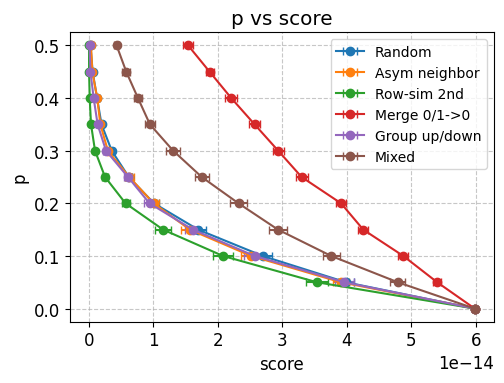

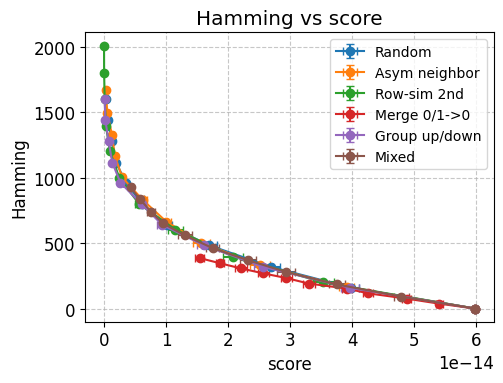

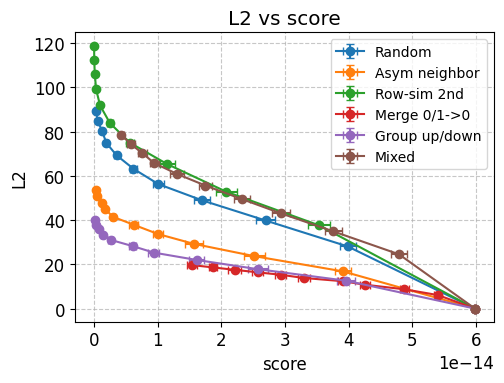

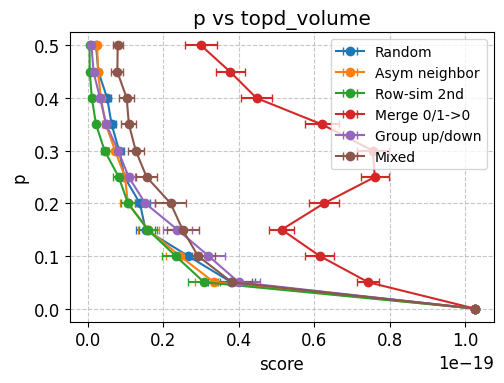

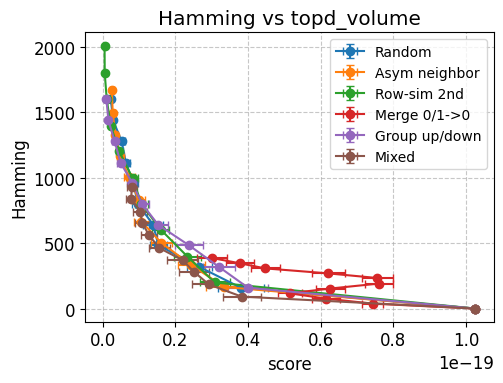

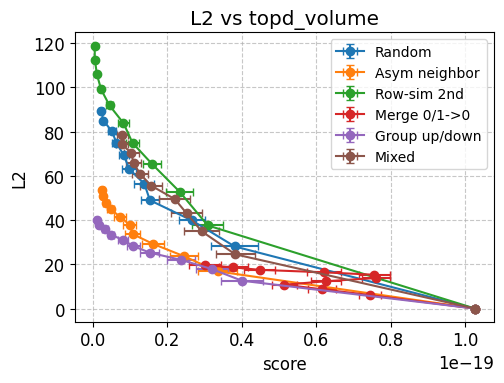

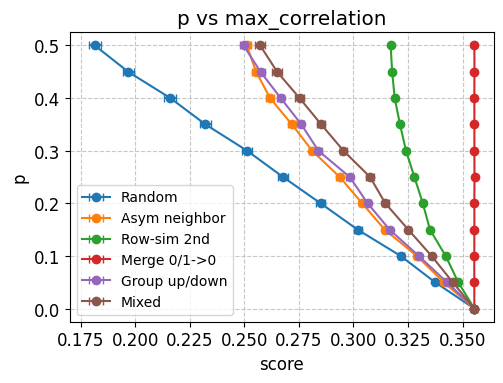

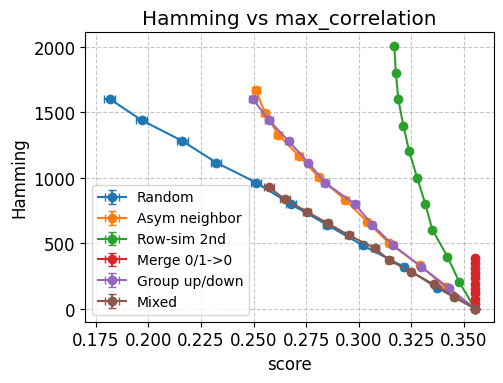

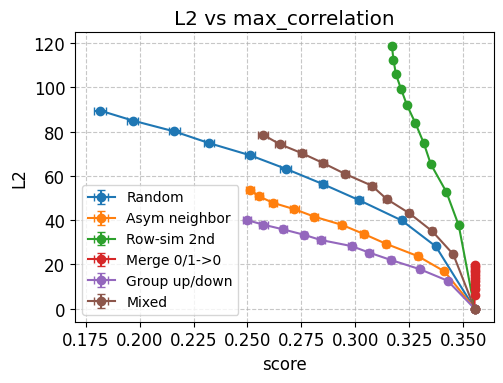

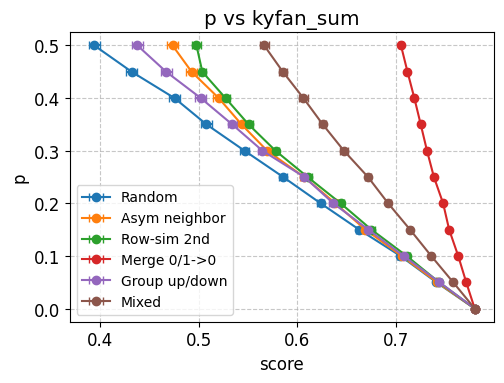

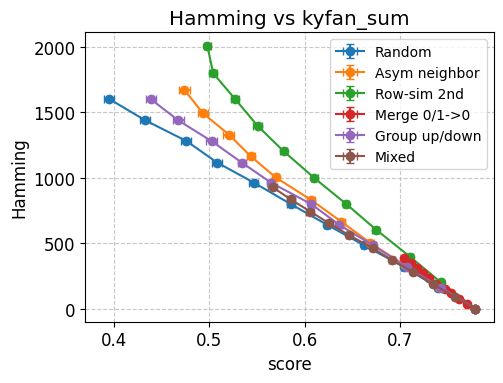

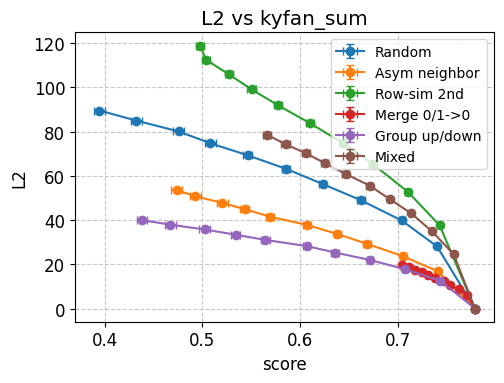

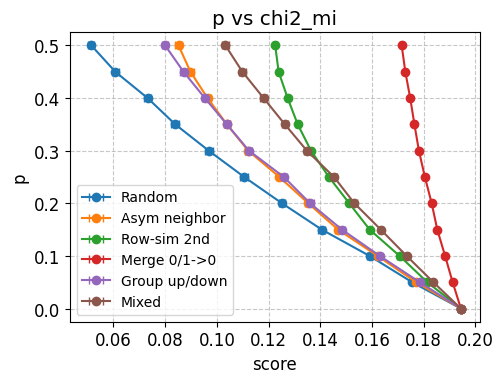

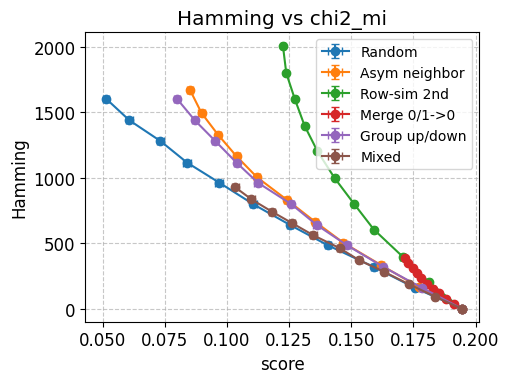

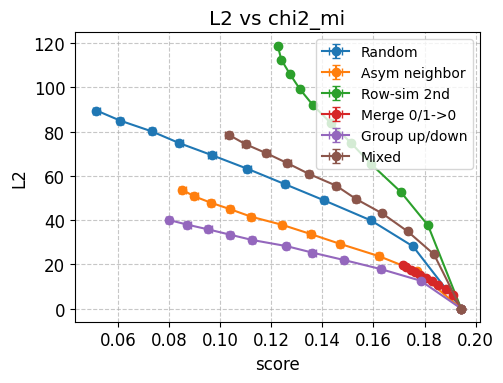

In [2]:
# =============================================================================
# Appendix G -- Score Comparison
# =============================================================================
# Compares five reliability scores across 5 manipulation policies, M=80 runs.
# Scores compared (all applied to the same empirical joint C[x^, y]):
#   - Gram determinant score  det(G^)^2  (Definition 4.5)
#   - topd_volume             product of singular values of whitened correlation
#   - max_correlation         largest singular value (maximal correlation)
#   - kyfan_sum               sum of singular values (Ky Fan 1-norm)
#   - chi2_mi                 sum of squared singular values (chi^2 mutual info)
# =============================================================================
# %%
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import det, norm, svd

# Reproducibility
rng = np.random.default_rng(42)

# -----------------------------
# Setup
# -----------------------------
n = 4000           # samples
d = 5              # classes
ps = np.arange(0.5, 1.0001, 0.05)  # keep-prob
n_runs = 80        # Monte Carlo runs

# Random ground-truth kernel P, rows sum to 1
P = rng.random((d, d))
P = P / P.sum(axis=1, keepdims=True)

# Data: true class X ~ Uniform{0..d-1}, and Y ~ P[X]
X = rng.integers(0, d, size=n)
Y = np.array([rng.choice(d, p=P[x]) for x in X])

# Precompute helpers
neighbor_plus = np.arange(d) + 1
neighbor_plus[-1] = d - 1
neighbor_minus = np.arange(d) - 1
neighbor_minus[0] = 0

# Row-sim 2nd: nearest other class by cosine similarity of P rows
row_norm = np.linalg.norm(P, axis=1, keepdims=True) + 1e-12
P_unit = P / row_norm
S = P_unit @ P_unit.T
np.fill_diagonal(S, -np.inf)
second_class = S.argmax(axis=1)

# Build empirical joint C[x^, y] (rows=reported class, cols=observation)
def build_joint(xh, y, d):
    G = np.zeros((d, d), dtype=float)
    np.add.at(G, (xh, y), 1)
    G /= len(xh)
    return G

# Compute all five scores from the joint table G
def compute_scores(G, eps=1e-12):
    # Marginals
    mu_x = G.sum(axis=1)   # empirical class frequency of x^
    mu_y = G.sum(axis=0)   # empirical observation frequency
    # Whitened residual matrix (removes marginal structure)
    Dx_inv_sqrt = np.diag(1.0 / np.sqrt(mu_x + eps))
    Dy_inv_sqrt = np.diag(1.0 / np.sqrt(mu_y + eps))
    Jbar = Dx_inv_sqrt @ (G - np.outer(mu_x, mu_y)) @ Dy_inv_sqrt
    s = svd(Jbar, compute_uv=False)  # singular values in decreasing order
    scores = {}
    scores["Gram determinant score"] = float(det(G) ** 2)  # Definition 4.5
    scores["topd_volume"] = float(np.prod(s))               # volume of singular-value parallelepiped
    scores["max_correlation"] = float(s[0])                 # maximal correlation coefficient
    scores["kyfan_sum"] = float(np.sum(s))                  # Ky Fan 1-norm
    scores["chi2_mi"] = float(np.sum(s**2))                 # chi^2 / mutual information proxy
    return scores

# -----------------------------
# Human-like confusion matrix P_human(y|x) -- Mixed policy (Section 5.1)
# -----------------------------
def human_like_confusion(d=5,
                         diag_strength=25.0,
                         off_strength=1.2,
                         beta=5.0,
                         default_bias=0.20,
                         default_label=0,
                         upcode_alpha=1.0,
                         topology="ring",
                         rng=None):
    rng = np.random.default_rng() if rng is None else rng
    idx = np.arange(d)
    if topology == "ring":
        dist = np.minimum(np.abs(idx[:, None] - idx[None, :]),
                          d - np.abs(idx[:, None] - idx[None, :]))
    elif topology == "line":
        dist = np.abs(idx[:, None] - idx[None, :])
    else:
        dist = np.zeros((d, d))
    S_sim = -dist.astype(float)

    Alpha = np.full((d, d), off_strength, float)
    np.fill_diagonal(Alpha, diag_strength)
    small = 1e-8
    for x in range(d):
        neigh = np.exp(beta * (S_sim[x] - S_sim[x].max()))
        up = np.exp(upcode_alpha * (np.arange(d) - x))
        bias = np.zeros(d); bias[default_label] = default_bias * diag_strength
        Alpha[x] = np.maximum(Alpha[x] + neigh + up + bias, small)
        Alpha[x, x] = max(Alpha[x, x], Alpha[x].max() + 1.0)

    P_h = np.zeros((d, d))
    for x in range(d):
        P_h[x] = rng.dirichlet(Alpha[x])
    return P_h

P_human = human_like_confusion(
    d=d,
    diag_strength=25.0,
    off_strength=1.2,
    beta=5.0,
    default_bias=0.20,
    default_label=0,
    upcode_alpha=1.0,
    topology="ring",
    rng=rng
)

def sample_rowwise(probs, rng):
    u = rng.random(probs.shape[0])
    cs = np.cumsum(probs, axis=1)
    return (u[:, None] > cs).sum(axis=1)

# Six manipulation policies (Section 5.1, Eq. 9)
def manip_uniform(X, mask):
    X_hat = X.copy()
    X_hat[~mask] = rng.integers(0, d, size=(~mask).sum())
    return X_hat

def manip_asym_neighbor(X, mask):
    X_hat = X.copy()
    idx = np.where(~mask)[0]
    if idx.size:
        toss = rng.random(idx.size)
        go_neighbor = toss < 0.85
        X_hat[idx[go_neighbor]] = neighbor_plus[X[idx[go_neighbor]]]
        rest = idx[~go_neighbor]
        if rest.size:
            choices = rng.integers(0, d-1, size=rest.size)
            choices += (choices >= X[rest]).astype(int)
            X_hat[rest] = choices
    return X_hat

def manip_instance_dep_xspace(X, mask):
    X_hat = X.copy()
    idx = np.where(~mask)[0]
    if idx.size:
        X_hat[idx] = second_class[X[idx]]
    return X_hat

def manip_coarsen_merge(X, mask):
    X_hat = X.copy()
    idx = np.where(~mask & np.isin(X, [0, 1]))[0]
    if idx.size:
        X_hat[idx] = 0
    return X_hat

def manip_upcode(X, mask):
    X_hat = X.copy()
    X_hat[~mask] = neighbor_plus[X[~mask]]
    return X_hat

def manip_group_policy(X, mask):
    Z = rng.integers(0, 2, size=X.size)
    X_hat = X.copy()
    idx = np.where(~mask)[0]
    if idx.size:
        up_idx = idx[Z[idx] == 1]
        dn_idx = idx[Z[idx] == 0]
        if up_idx.size:
            X_hat[up_idx] = neighbor_plus[X[up_idx]]
        if dn_idx.size:
            X_hat[dn_idx] = neighbor_minus[X[dn_idx]]
    return X_hat

def manip_human_like(X, mask):
    X_hat = X.copy()
    idx = np.where(~mask)[0]
    if idx.size:
        probs = P_human[X[idx]]
        X_hat[idx] = sample_rowwise(probs, rng)
    return X_hat

manipulators = {
    "Random":                manip_uniform,
    "Asym neighbor":         manip_asym_neighbor,
    "Row-sim 2nd":           manip_instance_dep_xspace,
    "Merge 0/1->0":          manip_coarsen_merge,
    # "Upcode (+1)":           manip_upcode,
    "Group up/down":         manip_group_policy,
    "Mixed":            manip_human_like,
}

# Which scores to compare
score_names = ["Gram determinant score", "topd_volume", "max_correlation", "kyfan_sum", "chi2_mi"]

# Containers
scores = {
    sname: {mname: np.zeros((len(ps), n_runs), dtype=float) for mname in manipulators}
    for sname in score_names
}
ham_runs = {mname: np.zeros((len(ps), n_runs), dtype=float) for mname in manipulators}
l2_runs  = {mname: np.zeros((len(ps), n_runs), dtype=float) for mname in manipulators}

# Main Monte Carlo loop
for ip, p in enumerate(ps):
    for jr in range(n_runs):
        mask = rng.random(n) < p
        for mname, fn in manipulators.items():
            X_hat = fn(X, mask)
            G = build_joint(X_hat, Y, d)
            sc = compute_scores(G)
            for sname in score_names:
                scores[sname][mname][ip, jr] = sc[sname]
            ham_runs[mname][ip, jr] = np.sum(X_hat != X)
            l2_runs[mname][ip, jr]  = norm(X_hat - X)

# Mean and 95% CI
def mean_ci(A):
    m = A.mean(axis=1)
    se = A.std(axis=1, ddof=1) / np.sqrt(A.shape[1])
    ci = 1.96 * se
    return m, ci

summary = {
    sname: {
        mname: {
            "m_score": mean_ci(scores[sname][mname])[0],
            "c_score": mean_ci(scores[sname][mname])[1],
            "m_ham":  mean_ci(ham_runs[mname])[0],
            "c_ham":  mean_ci(ham_runs[mname])[1],
            "m_l2":   mean_ci(l2_runs[mname])[0],
            "c_l2":   mean_ci(l2_runs[mname])[1],
        }
        for mname in manipulators
    }
    for sname in score_names
}

# -----------------------------
# Plotting -- three panels per score (p, Hamming, L2 vs score)
# -----------------------------
plt.rcParams.update({'font.size': 12})
figsize = (5.2, 4.0)
capsize = 3

for sname in score_names:
    # Panel (a): p vs score
    plt.figure(figsize=figsize)
    for mname in manipulators:
        ms = summary[sname][mname]["m_score"]
        cs = summary[sname][mname]["c_score"]
        plt.errorbar(ms, 1 - ps, xerr=cs, fmt='-o', capsize=capsize, label=mname)
    plt.xlabel('score')
    plt.ylabel('p')
    plt.title('p vs score' if sname == "Gram determinant score" else f'p vs {sname}')
    plt.grid(True, linestyle='--', linewidth=0.8, alpha=0.7)
    plt.legend(fontsize=10)
    plt.tight_layout()

    # Panel (b): Hamming vs score
    plt.figure(figsize=figsize)
    for mname in manipulators:
        ms = summary[sname][mname]["m_score"]
        cs = summary[sname][mname]["c_score"]
        mh = summary[sname][mname]["m_ham"]
        ch = summary[sname][mname]["c_ham"]
        plt.errorbar(ms, mh, xerr=cs, yerr=ch, fmt='-o', capsize=capsize, label=mname)
    plt.xlabel('score')
    plt.ylabel('Hamming')
    plt.title('Hamming vs score' if sname == "Gram determinant score" else f'Hamming vs {sname}')
    plt.grid(True, linestyle='--', linewidth=0.8, alpha=0.7)
    plt.legend(fontsize=10)
    plt.tight_layout()

    # Panel (c): L2 vs score
    plt.figure(figsize=figsize)
    for mname in manipulators:
        ms = summary[sname][mname]["m_score"]
        cs = summary[sname][mname]["c_score"]
        ml = summary[sname][mname]["m_l2"]
        cl = summary[sname][mname]["c_l2"]
        plt.errorbar(ms, ml, xerr=cs, yerr=cl, fmt='-o', capsize=capsize, label=mname)
    plt.xlabel('score')
    plt.ylabel('L2')
    plt.title('L2 vs score' if sname == "Gram determinant score" else f'L2 vs {sname}')
    plt.grid(True, linestyle='--', linewidth=0.8, alpha=0.7)
    plt.legend(fontsize=10)
    plt.tight_layout()

plt.show()
